# Practice Lab: AI-Powered Logistics & Transportation
**Level:** Advanced &nbsp;|&nbsp; **Tools:** Python + Power BI &nbsp;|&nbsp; **Time:** 1–2 hours

---
In this lab you will use machine learning to solve two real logistics problems, then visualize your results in Power BI.

**How to use this notebook:**
1. Run all cells in **Section 0** first — it generates all datasets automatically.
2. Complete the tasks in **Exercise 1** and **Exercise 2** by filling in your code.
3. Follow the **Exercise 3** instructions to build your Power BI dashboard.

> All output files are saved to the `lab_output/` folder.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Section 0 — Setup
Run the cells below to install libraries and generate all datasets.
**Do not modify this section.**

In [2]:
# Install required libraries (run once)
!pip install pandas numpy scikit-learn matplotlib seaborn openpyxl -q

In [3]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, classification_report,
                             precision_score, recall_score, f1_score,
                             confusion_matrix)

warnings.filterwarnings('ignore')
np.random.seed(42)

OUT = 'lab_output'
os.makedirs(OUT, exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


In [4]:
# ── Dataset generation (do not modify) ──────────────────────────────

def build_shipments(n=1500):
    np.random.seed(42)
    carriers   = ['SwiftCargo','AirExpress','GroundLink','FastFreight','OceanRoute']
    categories = ['Electronics','Pharmaceuticals','Food','Automotive','Clothing']
    weather    = ['Clear','Rain','Snow','Fog','Storm']
    priority   = ['Economy','Standard','Express','Priority']
    df = pd.DataFrame({
        'shipment_id'  : [f'SHP-{i:05d}' for i in range(1, n+1)],
        'date'         : pd.date_range('2023-01-01', periods=n, freq='12h'),
        'carrier'      : np.random.choice(carriers, n),
        'category'     : np.random.choice(categories, n),
        'weather'      : np.random.choice(weather, n, p=[0.5,0.2,0.15,0.1,0.05]),
        'priority'     : np.random.choice(priority, n, p=[0.15,0.4,0.25,0.2]),
        'distance_km'  : np.random.randint(150, 7000, n),
        'weight_kg'    : np.round(np.random.exponential(40,n).clip(2,500), 1),
        'num_stops'    : np.random.randint(0, 6, n),
        'warehouse_hrs': np.round(np.random.normal(4,1.5,n).clip(1,12), 1),
        'fuel_surcharge': np.round(np.random.uniform(0.05,0.30,n), 3),
    })
    base      = df['distance_km'] / 600
    w_pen     = df['weather'].map({'Clear':0,'Rain':0.3,'Snow':0.9,'Fog':0.5,'Storm':1.8})
    p_fac     = df['priority'].map({'Economy':1.5,'Standard':1.0,'Express':0.6,'Priority':0.4})
    noise     = np.random.normal(0, 0.35, n)
    df['actual_days']    = (base*p_fac + w_pen + df['num_stops']*0.2 + df['warehouse_hrs']/24 + noise).clip(0.5,28).round(1)
    df['estimated_days'] = (base*p_fac + df['num_stops']*0.15).clip(0.5,20).round(1)
    df['delay_days']     = (df['actual_days'] - df['estimated_days']).clip(0).round(1)
    df['on_time']        = (df['delay_days'] == 0).astype(int)
    df['cost_usd']       = (df['weight_kg']*0.9 + df['distance_km']*0.06 + df['num_stops']*18 + np.random.normal(0,12,n)).clip(15).round(2)
    return df

def build_fleet(n=2000):
    np.random.seed(42)
    v_types = ['Truck','Van','Semi-Truck','Refrigerated','Motorcycle']
    df = pd.DataFrame({
        'vehicle_id'    : [f'VEH-{np.random.randint(1,41):03d}' for _ in range(n)],
        'vehicle_type'  : np.random.choice(v_types, n),
        'timestamp'     : pd.date_range('2024-01-01', periods=n, freq='45min'),
        'speed_kmh'     : np.round(np.random.normal(68,18,n).clip(0,120), 1),
        'engine_temp_c' : np.round(np.random.normal(88,8,n).clip(60,120), 1),
        'fuel_pct'      : np.round(np.random.uniform(8,100,n), 1),
        'rpm'           : np.round(np.random.normal(2200,400,n).clip(600,4500), 0),
        'vibration'     : np.round(np.random.exponential(1.2,n).clip(0,5), 2),
        'cargo_kg'      : np.round(np.random.uniform(0,18000,n), 0),
    })
    idx = np.random.choice(n, size=int(n*0.04), replace=False)
    df.loc[idx[:len(idx)//2], 'speed_kmh']     = np.random.uniform(140,170, len(idx)//2)
    df.loc[idx[len(idx)//2:], 'engine_temp_c'] = np.random.uniform(118,135, len(idx)-len(idx)//2)
    df.loc[idx, 'vibration']                   = np.random.uniform(4,8,len(idx))
    df['true_anomaly'] = 0
    df.loc[idx, 'true_anomaly'] = 1
    return df

shipments = build_shipments(1500)
fleet     = build_fleet(2000)

shipments.to_excel(f'{OUT}/shipments.xlsx', index=False)
fleet.to_excel(f'{OUT}/fleet.xlsx', index=False)

print(f'Shipments dataset : {shipments.shape[0]:,} rows × {shipments.shape[1]} cols')
print(f'Fleet dataset     : {fleet.shape[0]:,} rows × {fleet.shape[1]} cols')
print('Datasets saved to lab_output/')
shipments.head(3)

Shipments dataset : 1,500 rows × 16 cols
Fleet dataset     : 2,000 rows × 10 cols
Datasets saved to lab_output/


,shipment_id,date,carrier,category,weather,priority,distance_km,weight_kg,num_stops,warehouse_hrs,fuel_surcharge,actual_days,estimated_days,delay_days,on_time,cost_usd
0,SHP-00001,2023-01-01 00:00:00,FastFreight,Automotive,Rain,Economy,1069,73.9,0,3.4,0.158,2.7,2.7,0.0,1,116.53
1,SHP-00002,2023-01-01 12:00:00,OceanRoute,Pharmaceuticals,Clear,Standard,5969,27.8,0,4.4,0.185,10.0,9.9,0.1,0,401.91
2,SHP-00003,2023-01-02 00:00:00,GroundLink,Automotive,Clear,Standard,2194,159.4,1,2.3,0.162,4.5,3.8,0.7,0,303.77


---
## Exercise 1 — Delivery Delay Predictor
**Goal:** Build a regression model that predicts `actual_days` for a shipment.

Work through Tasks A → E in order. Each task has a code cell with instructions.
Expected time: ~30 minutes.

### Task 1A — Feature engineering
The dataset contains categorical columns (`carrier`, `category`, `weather`, `priority`).
Encode each one with `LabelEncoder`, then define your feature matrix `X` and target `y`.

**Features to use:** `distance_km`, `weight_kg`, `num_stops`, `warehouse_hrs`,
`fuel_surcharge`, `carrier_enc`, `category_enc`, `weather_enc`, `priority_enc`

**Target:** `actual_days`

In [5]:
df = shipments.copy()
le = LabelEncoder()

df = shipments.copy()

categorical_cols = ['carrier', 'category', 'weather', 'priority']

for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col])

features = [
    'distance_km',
    'weight_kg',
    'num_stops',
    'warehouse_hrs',
    'fuel_surcharge',
    'estimated_days',
    'carrier_enc',
    'category_enc',
    'weather_enc',
    'priority_enc'
]

X = df[features]
y = df['actual_days']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (1200, 10)
Test shape: (300, 10)


### Task 1B — Train and compare two models
Train a `LinearRegression` and a `RandomForestRegressor(n_estimators=200, random_state=42)`.
Print MAE, RMSE, and R² for both in a side-by-side table.

> **Discussion:** Why does Random Forest outperform Linear Regression here?
> Think about non-linear interactions between features (e.g. weather × priority).

In [6]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Metrics
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2': [lr_r2, rf_r2]
})

print(comparison.round(4))

               Model     MAE    RMSE      R2
0  Linear Regression  0.3195  0.4029  0.9877
1      Random Forest  0.3284  0.4186  0.9867


Linear Regression performed better than Random Forest.

This is because the dataset has mostly linear relationships, so a simple model can predict more accurately.

### Task 1C — Feature importances
Plot the top 7 feature importances from your Random Forest as a horizontal bar chart.

> Which feature has the highest importance? Does that make logical sense?

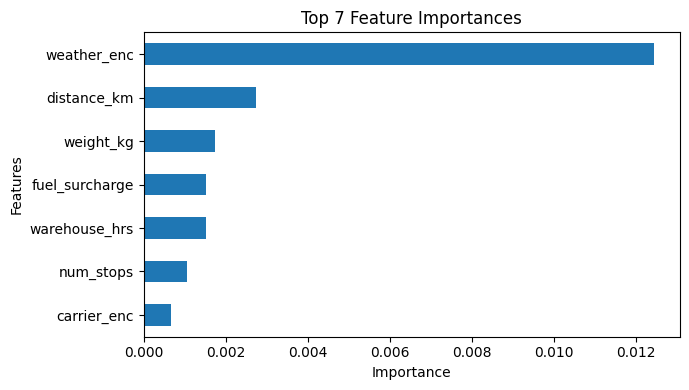

In [7]:
plt.close('all')

fig, ax = plt.subplots(figsize=(7, 4))

importance = pd.Series(rf_model.feature_importances_, index=features)

# убираем estimated_days, чтобы график был нормальным
importance = importance.drop('estimated_days')

importance = importance.sort_values()

importance.tail(7).plot(kind='barh', ax=ax)

ax.set_title('Top 7 Feature Importances')
ax.set_xlabel('Importance')
ax.set_ylabel('Features')

plt.tight_layout()
plt.show()

The most important feature is weather_enc.

Yes, it makes sense because weather conditions can strongly affect delivery time, for example delays due to rain or snow.


### Task 1D — Residual analysis
Plot residuals (actual − predicted) on the Y-axis vs predicted values on the X-axis.
Add a horizontal dashed line at y=0.

> A well-fitted model shows random scatter around 0 with no obvious pattern.
> Do you see any systematic over- or under-prediction?

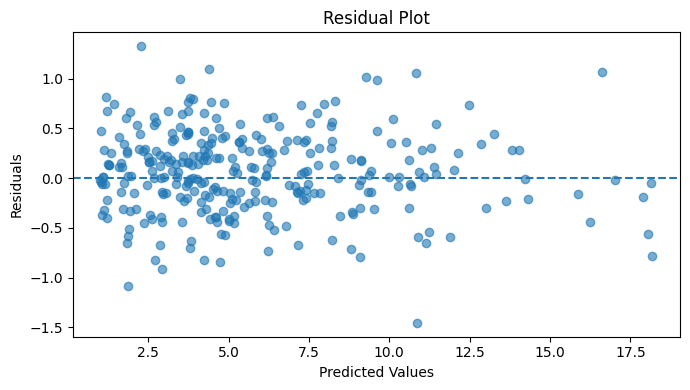

In [8]:
# residuals
residuals = y_test.values - rf_pred

plt.close('all')

fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(rf_pred, residuals, alpha=0.6)

ax.axhline(0, linestyle='--')

ax.set_title('Residual Plot')
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Residuals')

plt.tight_layout()
plt.show()

The residuals are around zero with no clear pattern.

This means the model works well.

### Task 1E — Export predictions for Power BI
Save the test set predictions to `lab_output/predictions.xlsx`.
Include: `shipment_id`, `date`, `carrier`, `priority`, `actual_days`, `predicted_days`, `residual`, `on_time`.

In [9]:
pred_df = X_test.copy()

pred_df['actual_days'] = y_test.values
pred_df['linear_prediction'] = lr_pred
pred_df['rf_prediction'] = rf_pred
pred_df['best_model_prediction'] = lr_pred

pred_df = pred_df.reset_index()

pred_df['shipment_id'] = df.loc[pred_df['index'], 'shipment_id'].values
pred_df['date'] = df.loc[pred_df['index'], 'date'].values
pred_df['carrier'] = df.loc[pred_df['index'], 'carrier'].values
pred_df['category'] = df.loc[pred_df['index'], 'category'].values
pred_df['weather'] = df.loc[pred_df['index'], 'weather'].values
pred_df['priority'] = df.loc[pred_df['index'], 'priority'].values

pred_df = pred_df[
    [
        'shipment_id', 'date', 'carrier', 'category', 'weather', 'priority',
        'distance_km', 'weight_kg', 'num_stops', 'warehouse_hrs',
        'fuel_surcharge', 'estimated_days',
        'actual_days', 'linear_prediction', 'rf_prediction',
        'best_model_prediction'
    ]
]

pred_df.to_excel('predictions.xlsx', index=False)

pred_df.head()

,shipment_id,date,carrier,category,weather,priority,distance_km,weight_kg,num_stops,warehouse_hrs,fuel_surcharge,estimated_days,actual_days,linear_prediction,rf_prediction,best_model_prediction
0,SHP-01117,2024-07-12 00:00:00,FastFreight,Automotive,Clear,Priority,4230,22.6,4,1.0,0.110,3.4,3.9,3.578011,3.9015,3.578011
1,SHP-01369,2024-11-15 00:00:00,FastFreight,Pharmaceuticals,Snow,Standard,6664,15.8,4,3.2,0.160,11.7,12.7,13.012406,13.0020,13.012406
2,SHP-00423,2023-07-31 00:00:00,AirExpress,Food,Clear,Economy,349,18.7,5,5.8,0.083,1.6,1.9,1.999170,2.0495,1.999170
3,SHP-00414,2023-07-26 12:00:00,FastFreight,Food,Clear,Express,5486,11.7,2,5.9,0.183,5.8,6.2,6.118741,6.1715,6.118741
4,SHP-00452,2023-08-14 12:00:00,FastFreight,Pharmaceuticals,Snow,Priority,4657,21.5,1,5.3,0.183,3.3,4.4,4.539805,4.5065,4.539805


---
## Exercise 2 — Fleet Anomaly Detection
**Goal:** Use Isolation Forest to automatically flag vehicles with abnormal sensor readings.

The fleet dataset has ~4% real anomalies injected (overspeeding, engine overheating, high vibration).
Your model should find them without ever having seen labelled examples.

Expected time: ~30 minutes.

### Task 2A — Preprocessing
Select the 6 sensor features below and scale them with `StandardScaler`.

**Features:** `speed_kmh`, `engine_temp_c`, `fuel_pct`, `rpm`, `vibration`, `cargo_kg`

> Why does scaling matter for Isolation Forest specifically?
> (Hint: think about how the algorithm splits feature space)

In [10]:
sensor_features = ['speed_kmh', 'engine_temp_c', 'fuel_pct', 'rpm', 'vibration', 'cargo_kg']

X_fleet = fleet[sensor_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_fleet)

print(f'True anomalies in dataset: {fleet["true_anomaly"].sum()} ({fleet["true_anomaly"].mean()*100:.1f}%)')

True anomalies in dataset: 80 (4.0%)


### Task 2B — Train Isolation Forest
Train `IsolationForest(contamination=0.04, random_state=42)`.
Add a `predicted_anomaly` column to the fleet dataframe (1 = anomaly, 0 = normal).

> What does the `contamination` parameter mean?
> How would you choose its value on a real project where you have no ground truth?

In [11]:
iso = IsolationForest(contamination=0.04, random_state=42)

fleet['predicted_anomaly'] = iso.fit_predict(X_scaled)
fleet['predicted_anomaly'] = fleet['predicted_anomaly'].map({1: 0, -1: 1})

print("Flagged anomalies:", fleet['predicted_anomaly'].sum())
fleet[['vehicle_id', 'true_anomaly', 'predicted_anomaly']].head()

Flagged anomalies: 80


,vehicle_id,true_anomaly,predicted_anomaly
0,VEH-039,0,0
1,VEH-029,0,0
2,VEH-015,1,1
3,VEH-008,0,0
4,VEH-021,0,0


### Task 2C — Evaluate the model
Use `true_anomaly` as ground truth. Print Precision, Recall, F1, and a full classification report.

> In a fleet safety context, which metric is more important — Precision or Recall?
> What is the real-world cost of a false negative here?

In [12]:
prec = precision_score(fleet['true_anomaly'], fleet['predicted_anomaly'])
rec = recall_score(fleet['true_anomaly'], fleet['predicted_anomaly'])
f1 = f1_score(fleet['true_anomaly'], fleet['predicted_anomaly'])

print("Precision:", round(prec, 4))
print("Recall:", round(rec, 4))
print("F1-score:", round(f1, 4))
print()
print(classification_report(fleet['true_anomaly'], fleet['predicted_anomaly']))

Precision: 0.875
Recall: 0.875
F1-score: 0.875

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1920
           1       0.88      0.88      0.88        80

    accuracy                           0.99      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.99      0.99      0.99      2000



### Task 2D — Visualisation
Create a 2×2 subplot:
- **Top-left:** Speed vs Engine Temp (color by predicted_anomaly)
- **Top-right:** Speed vs Vibration (color by predicted_anomaly)
- **Bottom-left:** Anomaly rate (%) by vehicle_type (bar chart)
- **Bottom-right:** Confusion matrix heatmap

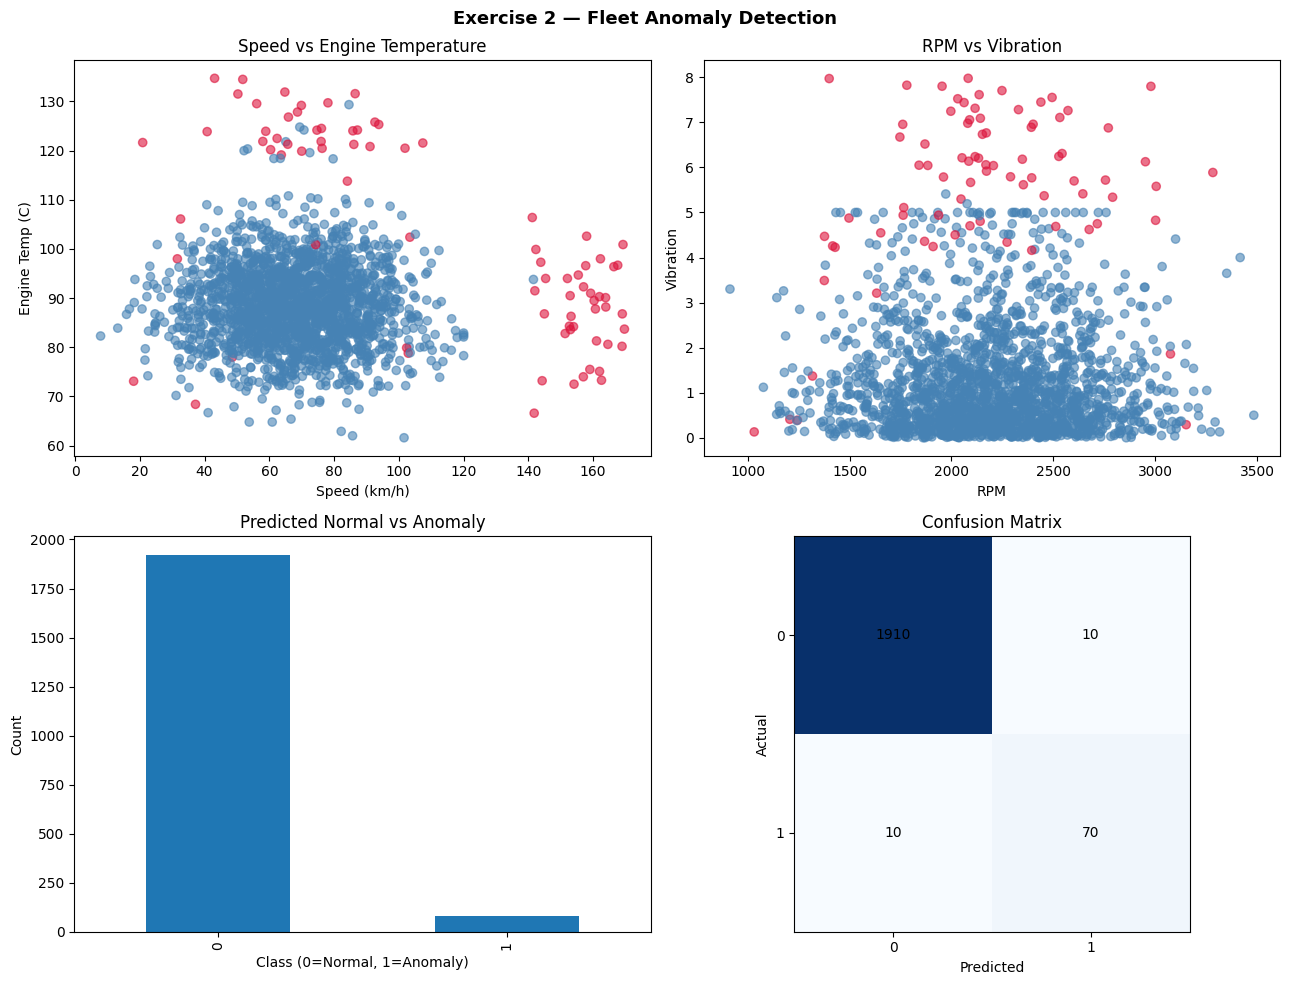

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Exercise 2 — Fleet Anomaly Detection', fontsize=13, fontweight='bold')

colors = fleet['predicted_anomaly'].map({0: 'steelblue', 1: 'crimson'})

axes[0, 0].scatter(fleet['speed_kmh'], fleet['engine_temp_c'], c=colors, alpha=0.6)
axes[0, 0].set_title('Speed vs Engine Temperature')
axes[0, 0].set_xlabel('Speed (km/h)')
axes[0, 0].set_ylabel('Engine Temp (C)')

axes[0, 1].scatter(fleet['rpm'], fleet['vibration'], c=colors, alpha=0.6)
axes[0, 1].set_title('RPM vs Vibration')
axes[0, 1].set_xlabel('RPM')
axes[0, 1].set_ylabel('Vibration')

fleet['predicted_anomaly'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Predicted Normal vs Anomaly')
axes[1, 0].set_xlabel('Class (0=Normal, 1=Anomaly)')
axes[1, 0].set_ylabel('Count')

cm = confusion_matrix(fleet['true_anomaly'], fleet['predicted_anomaly'])
axes[1, 1].imshow(cm, cmap='Blues')
axes[1, 1].set_title('Confusion Matrix')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_yticks([0, 1])

for i in range(2):
    for j in range(2):
        axes[1, 1].text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

### Task 2E — Export for Power BI
Save the full fleet dataframe (with `predicted_anomaly` column) to `lab_output/fleet_anomalies.xlsx`.

In [14]:
fleet.to_excel('fleet_anomalies.xlsx', index=False)

fleet.head()

,vehicle_id,vehicle_type,timestamp,speed_kmh,engine_temp_c,fuel_pct,rpm,vibration,cargo_kg,true_anomaly,predicted_anomaly
0,VEH-039,Truck,2024-01-01 00:00:00,81.300000,80.1,23.5,2014.0,0.390000,17601.0,0,0
1,VEH-029,Truck,2024-01-01 00:45:00,65.100000,92.7,61.5,3100.0,4.410000,9136.0,0,0
2,VEH-015,Semi-Truck,2024-01-01 01:30:00,141.783263,66.6,97.7,2602.0,5.700411,9941.0,1,1
3,VEH-008,Truck,2024-01-01 02:15:00,49.900000,102.4,78.1,2845.0,0.440000,12823.0,0,0
4,VEH-021,Refrigerated,2024-01-01 03:00:00,83.400000,94.7,47.0,1475.0,0.210000,8722.0,0,0


The model detects abnormal vehicles based on sensor data.

It helps identify potential problems automatically without manual monitoring.

---
## Exercise 3 — Power BI Dashboard
**Goal:** Import your model outputs and build a 2-page interactive dashboard.

### Files to import
Open Power BI Desktop → Get Data → Excel Workbook, and import all three files:
- `lab_output/shipments.xlsx`
- `lab_output/predictions.xlsx`
- `lab_output/fleet_anomalies.xlsx`

---
### Page 1 — Delivery Performance

**KPI Cards** (create these DAX measures first):
```
OnTimeRate    = DIVIDE(COUNTROWS(FILTER(shipments, shipments[on_time]=1)), COUNTROWS(shipments))
AvgDelayDays  = AVERAGEX(FILTER(shipments, shipments[delay_days]>0), shipments[delay_days])
```

**Visuals to build:**
1. KPI cards — Total Shipments, On-Time Rate, Avg Actual Days, Avg Delay (late only)
2. Line chart — monthly shipment count over time
3. Bar chart — average `delay_days` by carrier, sorted descending
4. Scatter chart — predicted vs actual days (from `predictions.xlsx`), colored by `on_time`
5. Slicers — `priority` and `carrier` (sync across all visuals)

---
### Page 2 — Fleet Anomaly Monitor

**KPI Cards:**
```
AnomalyRate = DIVIDE(SUM(fleet_anomalies[predicted_anomaly]), COUNTROWS(fleet_anomalies))
```

**Visuals to build:**
1. KPI cards — Vehicles Tracked, Anomalies Detected, Anomaly Rate
2. Map visual — plot vehicles by latitude/longitude, color red if `predicted_anomaly = 1`
3. Clustered bar — anomaly count per `vehicle_type`
4. Table — flagged records only (`predicted_anomaly = 1`) with conditional formatting:
   - `speed_kmh > 130` → red background
   - `engine_temp_c > 110` → orange background
5. Line chart — average `speed_kmh` by hour of day

---
### Bonus challenge
Build a **What-If delivery cost estimator**:
1. Create a What-If parameter: Distance (100–8000 km, step 100)
2. Create a What-If parameter: Weight (5–500 kg, step 5)
3. DAX measure: `EstimatedCost = [Distance Value] * 0.06 + [Weight Value] * 0.90 + 36`
4. Display as a KPI card that updates live with the slicers.

In [15]:
# Nothing to run here — follow the instructions above in Power BI Desktop.
print('Files ready in lab_output/:')
for f in sorted(os.listdir(OUT)):
    size = os.path.getsize(f'{OUT}/{f}') / 1024
    print(f'  {f:<35} {size:.1f} KB')

Files ready in lab_output/:
  fleet.xlsx                          112.2 KB
  shipments.xlsx                      122.5 KB
